# Linearn binary classifiers

### Exercice 1

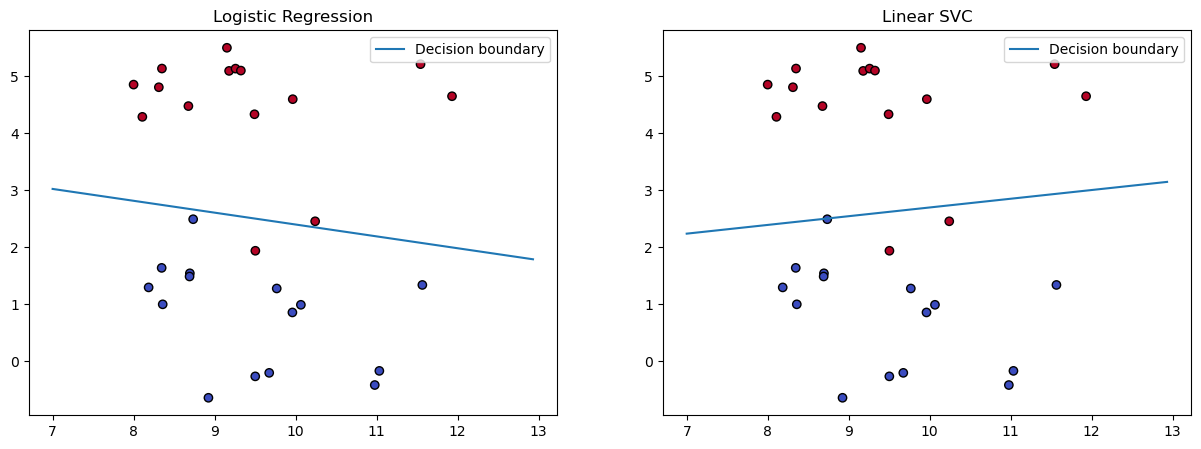

Score d'entraînement de Logistic Regression : 0.97
Score d'entraînement de Linear SVC : 0.93


In [19]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import numpy as np

X, y = make_blobs(n_samples=30, centers=2, random_state=4)

logreg = LogisticRegression()
linsvc = LinearSVC()

logreg.fit(X, y)
linsvc.fit(X, y)

def plot_decision_boundary(model, X, y, ax, title):
    coef = model.coef_[0]  # Coefficients (a, b)
    intercept = model.intercept_  # Intercept (c)

    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    
    y_vals = -(coef[0] * x_vals + intercept) / coef[1]

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    
    ax.plot(x_vals, y_vals, linestyle='solid', label="Decision boundary")

    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_decision_boundary(logreg, X, y, axes[0], "Logistic Regression")
plot_decision_boundary(linsvc, X, y, axes[1], "Linear SVC")

plt.show()

print(f"Score d'entraînement de Logistic Regression : {logreg.score(X, y):.2f}")
print(f"Score d'entraînement de Linear SVC : {linsvc.score(X, y):.2f}")


### Observations :

**Scores d'entraînement :**

- Logistic Regression : 0.97
- Linear SVC : 0.93
- Les deux modèles ont de bons scores d'entraînement, mais Logistic Regression semble un peu mieux ajusté aux données.

**Courbes de décision :**

- Logistic Regression : Un point rouge est en dessous de la frontière, mais les autres sont bien classés au-dessus.
- Linear SVC : Deux points rouges sont en dessous de la frontière, ce qui montre que Linear SVC sépare moins bien les données

**Régularisation (C) :**

- Logistic Regression : Le paramètre C est par défaut moins strict, ce qui rend le modèle plus flexible et tolérant aux erreurs (d'où un point rouge mal classé).
- Linear SVC : Le paramètre C est plus élevé, ce qui rend le modèle plus rigide et impose une séparation plus stricte, d'où la présence de deux points rouges mal classés.

**Conclusion :**

Logistic Regression est plus flexible, permettant un point mal classé. Linear SVC a une frontière plus rigide, forçant une séparation plus stricte.

### Exercice 2 :

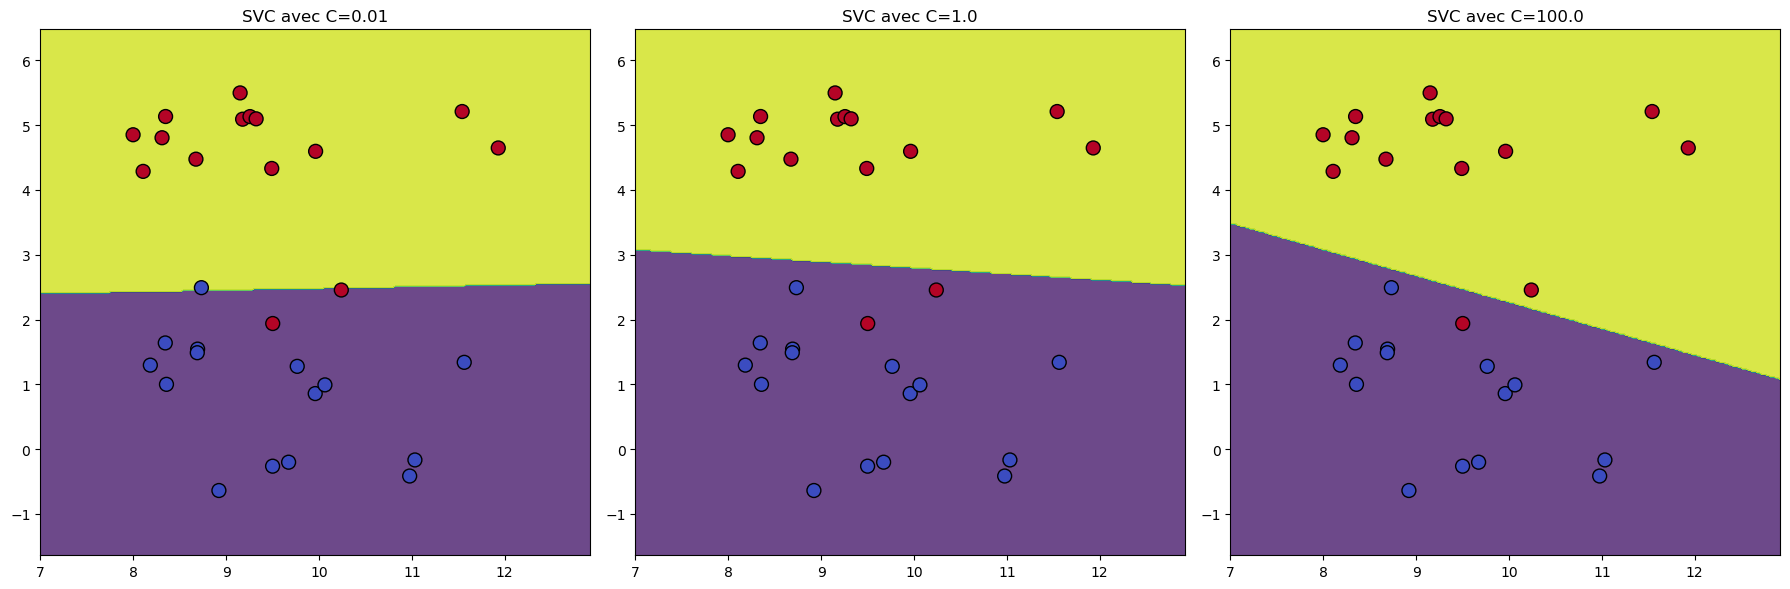

Training score for SVC with C=0.01: 0.90
Training score for SVC with C=1.0: 0.93
Training score for SVC with C=100.0: 0.97


In [22]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import numpy as np

def plot_decision_boundary(model, X, y, ax, title, C_value):
    h = 0.02  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap='coolwarm')
    ax.set_title(f"SVC avec C={C_value}")

X, y = make_blobs(n_samples=30, centers=2, random_state=4)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, C_value in enumerate([0.01, 1.0, 100.0]):
    svc = SVC(kernel='linear', C=C_value)
    svc.fit(X, y)
    plot_decision_boundary(svc, X, y, axes[i], "Linear SVC", C_value)

plt.tight_layout()
plt.show()

for C_value in [0.01, 1.0, 100.0]:
    svc = SVC(kernel='linear', C=C_value)
    svc.fit(X, y)
    print(f"Training score for SVC with C={C_value}: {svc.score(X, y):.2f}")

**Observations :** 
- Plus C augmente et plus la ligne s'incline vers le bas. 
- Cela fait augmenter le score d'entraînement.

### Exercice 3 :

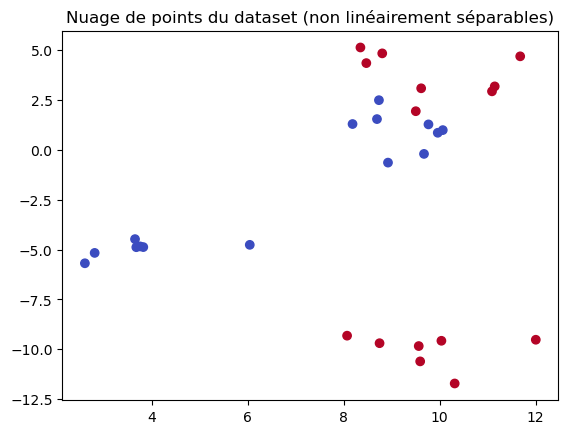

Score d'entraînement avec Linear SVC : 0.73
Score d'entraînement avec Polynomial SVC : 0.97
Score d'entraînement avec RBF SVC : 0.97


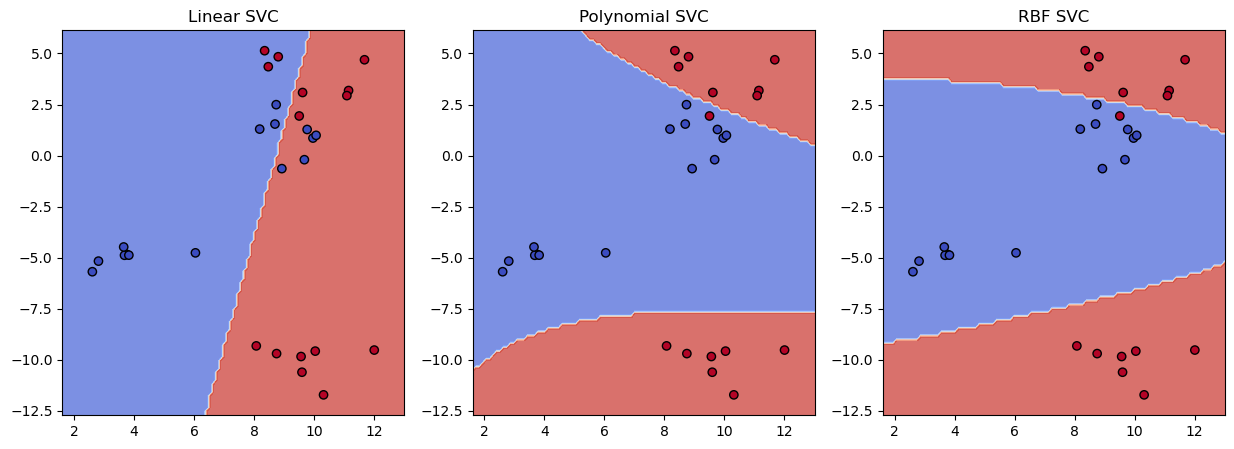

In [35]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import numpy as np

X, y = make_blobs(n_samples=30, centers=4, random_state=4)
y = y % 2

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title("Nuage de points du dataset (non linéairement séparables)")
plt.show()

linear_svc = SVC(kernel='linear')
poly_svc = SVC(kernel='poly', degree=3)
rbf_svc = SVC(kernel='rbf')

linear_svc.fit(X, y)
poly_svc.fit(X, y)
rbf_svc.fit(X, y)

print(f"Score d'entraînement avec Linear SVC : {linear_svc.score(X, y):.2f}")
print(f"Score d'entraînement avec Polynomial SVC : {poly_svc.score(X, y):.2f}")
print(f"Score d'entraînement avec RBF SVC : {rbf_svc.score(X, y):.2f}")

def plot_decision_boundary(model, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.75, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_decision_boundary(linear_svc, axes[0], "Linear SVC")
plot_decision_boundary(poly_svc, axes[1], "Polynomial SVC")
plot_decision_boundary(rbf_svc, axes[2], "RBF SVC")

plt.show()


**Observations :**

- Le **SVC linéaire** a un score plus bas (0.73) car les données ne sont **pas linéairement séparables**. Un modèle linéaire essaie de tracer une frontière droite pour séparer les deux classes, mais cela ne fonctionne pas bien pour des données qui ne suivent pas une relation linéaire. Ce modèle est donc moins performant sur ce jeu de données non linéaire.

- Les modèles **polynomial** et **RBF (Gaussian)** ont des scores plus élevés (0.97) car ils utilisent des noyaux qui permettent de créer des frontières de décision **non linéaires**, adaptées aux données complexes. Ces noyaux permettent de mieux capturer la structure des données et d'obtenir une séparation plus précise des classes.

### Exercice 4 :

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=100, n_informative=10, noise=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_reg = LinearRegression()
lasso_reg = Lasso()
ridge_reg = Ridge()

linear_reg.fit(X_train, y_train)
lasso_reg.fit(X_train, y_train)
ridge_reg.fit(X_train, y_train)

y_pred_linear = linear_reg.predict(X_test)
y_pred_lasso = lasso_reg.predict(X_test)
y_pred_ridge = ridge_reg.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Score de régression linéaire : {linear_reg.score(X_test, y_test):.4f}")
print(f"Score de Lasso : {lasso_reg.score(X_test, y_test):.4f}")
print(f"Score de Ridge : {ridge_reg.score(X_test, y_test):.4f}")

print(f"Erreur quadratique moyenne (MSE) pour la régression linéaire : {mse_linear:.4f}")
print(f"Erreur quadratique moyenne (MSE) pour Lasso : {mse_lasso:.4f}")
print(f"Erreur quadratique moyenne (MSE) pour Ridge : {mse_ridge:.4f}")
print()

# Différentes valeurs du paramètre alpha pour Lasso
alphas = [0.1, 1, 10]
for alpha in alphas:
    lasso_reg = Lasso(alpha=alpha)
    lasso_reg.fit(X_train, y_train)
    y_pred_lasso = lasso_reg.predict(X_test)
    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    print(f"Score de Lasso avec alpha={alpha} : {lasso_reg.score(X_test, y_test):.4f}")
    print(f"MSE Lasso avec alpha={alpha} : {mse_lasso:.4f}")


Score de régression linéaire : 1.0000
Score de Lasso : 0.9996
Score de Ridge : 1.0000
Erreur quadratique moyenne (MSE) pour la régression linéaire : 1.0519
Erreur quadratique moyenne (MSE) pour Lasso : 13.1015
Erreur quadratique moyenne (MSE) pour Ridge : 1.1654

Score de Lasso avec alpha=0.1 : 1.0000
MSE Lasso avec alpha=0.1 : 1.1563
Score de Lasso avec alpha=1 : 0.9996
MSE Lasso avec alpha=1 : 13.1015
Score de Lasso avec alpha=10 : 0.9674
MSE Lasso avec alpha=10 : 984.7796


1. **Quel algorithme performe le mieux ? Pourquoi ?**
   - **Régression linéaire** et **Ridge** sont les meilleurs avec un score parfait de **1.0000**, car ils sont moins sensibles aux erreurs de régularisation. **Lasso** a un score légèrement inférieur (**0.9996**), mais génère un MSE beaucoup plus élevé.


2. **Impact de alpha sur Lasso :**
   - **alpha=0.1** : Meilleur score (**1.0000**) et MSE faible (**1.1563**).
   - **alpha=1** : Score légèrement réduit (**0.9996**) et MSE plus élevé (**13.1015**).
   - **alpha=10** : Score faible (**0.9674**) et MSE très élevé (**984.7796**).

3. **Pourquoi ces variations ?**
   - Lasso avec un **alpha élevé** pénalise excessivement les coefficients, ce qui réduit la complexité mais augmente l'erreur. Un **alpha plus faible** permet de mieux ajuster le modèle aux données, obtenant ainsi une meilleure performance.

4. **Quel alpha est préférable pour ce dataset ?**
   - **alpha=0.1** est préférable, car il offre un bon compromis entre régularisation et performance.
